# Toronto Neighbourhood Political Clustering

Inspired by the [SF Chronicle's California political groups project](https://www.sfchronicle.com/projects/2026/california-political-groups/),
we cluster Toronto's 585 census tracts based on their voting behaviour across three recent elections:
the **2023 mayoral race**, the **2025 Ontario provincial election**, and the **2025 federal election**.

**Key design choices:**
- Features are **city-relative deviations** (tract minus citywide average, in percentage points) — interpretable and centred
- **Block weighting** equalises the contribution of each election; without it, the federal election (highest turnout, most spread) would dominate PCA
- **PCA** is used for clustering (deterministic, distance-preserving); UMAP is kept as a visualisation layer only
- A **riding-residual diagnostic** tests whether the clusters reflect genuine neighbourhood character or are primarily an artefact of riding-level electoral effects

In [1]:
import json
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import fcluster, linkage
from shapely.geometry import box as shapely_box
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import umap
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

In [2]:
ROOT = Path("../..")
MAP_DIR    = ROOT / "data/toronto_election_turnout/interpolation/map"
RIDING_DIR = ROOT / "data/toronto_election_turnout/elections/raw"
OUT_ROOT   = ROOT / "data/clustering_neighbourhoods"
PROFILES_DIR = OUT_ROOT / "profiles"   # reusable GeoPackages and CSVs
FIGURES_DIR  = OUT_ROOT / "figures"    # publication-quality PNGs
EXPLORE_DIR  = OUT_ROOT / "explore"    # exploratory outputs and diagnostics
for d in [PROFILES_DIR, FIGURES_DIR, EXPLORE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MUN_CANDIDATE_KEYS = {
    "chow":     "Chow Olivia",
    "bailao":   "Bailão Ana",
    "saunders": "Saunders Mark",
    "furey":    "Furey Anthony",
    "matlow":   "Matlow Josh",
}
PROV_PARTY_KEYS = {
    "pc":      "progressive_conservative_party_of_ontario",
    "ndp":     "new_democratic_party_of_ontario",
    "liberal": "ontario_liberal_party",
    "green":   "green_party_of_ontario",
}
FED_PARTY_KEYS = {
    "liberal":      "liberal",
    "conservative": "conservative",
    "ndp":          "ndp_new_democratic_party",
    "green":        "green_party",
}

ALL_COLS = [
    "mun_turnout",
    "mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other",
    "prov_turnout",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other",
    "fed_turnout",
    "fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other",
]
TURNOUT_COLS    = ["mun_turnout", "prov_turnout", "fed_turnout"]
MUN_SHARE_COLS  = ["mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other"]
PROV_SHARE_COLS = ["prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other"]
FED_SHARE_COLS  = ["fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other"]
SHARE_COLS      = MUN_SHARE_COLS + PROV_SHARE_COLS + FED_SHARE_COLS

# Each block = turnout + vote shares for one election.
# Block weighting will standardise within each block then scale it to unit total variance,
# so no election dominates PCA regardless of its raw variance.
ELECTION_BLOCKS = {
    "municipal":  ["mun_turnout"]  + MUN_SHARE_COLS,   # 7 features
    "provincial": ["prov_turnout"] + PROV_SHARE_COLS,  # 6 features
    "federal":    ["fed_turnout"]  + FED_SHARE_COLS,   # 6 features
}

N_CLUSTERS_RANGE = [4, 5, 6, 7]
K_CHOSEN     = 5          # updated after silhouette analysis in §4
RANDOM_STATE = 42
PALETTE = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#264653", "#a8dadc"]

## 1. Data Loading & Feature Extraction

Each GeoJSON has a `party_votes` / `candidate_votes` property stored as a nested JSON object.
Vote **share** for each candidate/party is `estimated_votes / estimated_valid_candidate_votes`,
so shares sum to 1 within each election. The `other` bucket absorbs every minor candidate
not named above.

Citywide averages are population-weighted (by `estimated_valid_candidate_votes`) so they
reflect the true city-level result, not an unweighted tract mean.

In [3]:
def _parse_json(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):  return json.loads(val) if val else {}
    return {}

def load_gdf(filename):
    gdf = gpd.read_file(MAP_DIR / filename)
    for col in ["party_votes", "candidate_votes", "top_candidates"]:
        if col in gdf.columns:
            gdf[col] = gdf[col].apply(_parse_json)
    return gdf

mun_gdf  = load_gdf("municipal_2023_mayor_ct_map.geojson")
prov_gdf = load_gdf("provincial_2025_ct_map.geojson")
fed_gdf  = load_gdf("federal_2025_ct_map.geojson")
print(f"Municipal CTs:  {len(mun_gdf)}")
print(f"Provincial CTs: {len(prov_gdf)}")
print(f"Federal CTs:    {len(fed_gdf)}")

Municipal CTs:  585
Provincial CTs: 585
Federal CTs:    585


In [4]:
def _safe_share(votes, total):
    return votes / total if total > 0 else 0.0

def extract_mun_features(row):
    cvotes = row["candidate_votes"]
    total  = row["estimated_valid_candidate_votes"]
    shares = {f"mun_{k}": _safe_share(cvotes.get(v, 0.0), total)
              for k, v in MUN_CANDIDATE_KEYS.items()}
    shares["mun_other"]   = max(0.0, 1.0 - sum(shares.values()))
    shares["mun_turnout"] = row["estimated_turnout"]
    return shares

def extract_prov_features(row):
    pvotes = row["party_votes"]
    total  = row["estimated_valid_candidate_votes"]
    shares = {f"prov_{k}": _safe_share(pvotes.get(v, 0.0), total)
              for k, v in PROV_PARTY_KEYS.items()}
    shares["prov_other"]   = max(0.0, 1.0 - sum(shares.values()))
    shares["prov_turnout"] = row["estimated_turnout"]
    return shares

def extract_fed_features(row):
    pvotes = row["party_votes"]
    total  = row["estimated_valid_candidate_votes"]
    shares = {f"fed_{k}": _safe_share(pvotes.get(v, 0.0), total)
              for k, v in FED_PARTY_KEYS.items()}
    shares["fed_other"]   = max(0.0, 1.0 - sum(shares.values()))
    shares["fed_turnout"] = row["estimated_turnout"]
    return shares

with tqdm(total=3, desc="Extracting features") as pbar:
    mun_feats  = pd.DataFrame([extract_mun_features(r)  for _, r in mun_gdf.iterrows()],  index=mun_gdf["ct_id"])
    pbar.update()
    prov_feats = pd.DataFrame([extract_prov_features(r) for _, r in prov_gdf.iterrows()], index=prov_gdf["ct_id"])
    pbar.update()
    fed_feats  = pd.DataFrame([extract_fed_features(r)  for _, r in fed_gdf.iterrows()],  index=fed_gdf["ct_id"])
    pbar.update()

raw_df = mun_feats.join(prov_feats, how="inner").join(fed_feats, how="inner")[ALL_COLS]

n_nan = raw_df.isna().sum().sum()
if n_nan > 0:
    print(f"Imputing {n_nan} NaN value(s) with column mean")
    raw_df = raw_df.fillna(raw_df.mean())

geom_df = mun_gdf.set_index("ct_id")[["geometry"]]
raw_gdf = gpd.GeoDataFrame(
    raw_df.join(geom_df, how="inner").reset_index(),
    geometry="geometry", crs=mun_gdf.crs,
)
print(f"\nFinal dataset: {len(raw_gdf)} census tracts × {len(ALL_COLS)} features")

# Flag CTs where no named-party votes were recorded in ≥1 election.
# Interpolation returns 0 for all named parties, so 'other' absorbs 100%.
# These are excluded from K-means fitting and assigned to the nearest centroid post-hoc.
_anom = (raw_gdf["mun_other"] >= 0.99) | (raw_gdf["prov_other"] >= 0.99) | (raw_gdf["fed_other"] >= 0.99)
anomaly_mask = _anom.values   # numpy bool array, len = n_tracts
n_anom = anomaly_mask.sum()
if n_anom:
    print(f"Data anomalies: {n_anom} CT(s) with no named-party data in ≥1 election "
          f"({raw_gdf.loc[_anom, 'ct_id'].values})")
    print("  → excluded from K-means fitting; assigned to nearest centroid post-hoc")
else:
    print("No data anomalies detected")

raw_gdf[ALL_COLS].describe().round(3)

Extracting features:   0%|          | 0/3 [00:00<?, ?it/s]

Imputing 5 NaN value(s) with column mean

Final dataset: 585 census tracts × 19 features
Data anomalies: 2 CT(s) with no named-party data in ≥1 election (['5350006.00' '5350205.00'])
  → excluded from K-means fitting; assigned to nearest centroid post-hoc


,mun_turnout,mun_chow,mun_bailao,mun_saunders,mun_furey,mun_matlow,mun_other,prov_turnout,prov_pc,prov_ndp,prov_liberal,prov_green,prov_other,fed_turnout,fed_liberal,fed_conservative,fed_ndp,fed_green,fed_other
count,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000
mean,0.374,0.367,0.319,0.090,0.049,0.045,0.130,0.426,0.351,0.221,0.382,0.027,0.019,0.649,0.579,0.340,0.064,0.007,0.011
std,0.092,0.115,0.095,0.034,0.017,0.038,0.074,0.065,0.142,0.200,0.109,0.008,0.046,0.077,0.072,0.102,0.060,0.006,0.058
min,0.141,0.000,0.000,0.000,0.000,0.000,0.038,0.134,0.000,0.000,0.000,0.000,0.000,0.428,0.000,0.000,0.000,0.000,0.000
25%,0.316,0.282,0.249,0.059,0.036,0.023,0.094,0.379,0.224,0.057,0.298,0.022,0.007,0.595,0.540,0.264,0.027,0.000,0.000
50%,0.366,0.353,0.310,0.097,0.048,0.037,0.116,0.425,0.361,0.092,0.384,0.026,0.014,0.646,0.586,0.344,0.036,0.008,0.006
75%,0.438,0.450,0.372,0.114,0.060,0.052,0.149,0.476,0.460,0.403,0.457,0.031,0.020,0.698,0.628,0.416,0.078,0.011,0.011
max,1.462,0.777,0.611,0.180,0.105,0.245,1.000,0.600,0.672,0.798,0.638,0.051,1.000,0.960,0.706,0.632,0.318,0.040,1.000


In [5]:
# ── Citywide averages (vote-weighted) ────────────────────────────────────────
citywide = {}

mun_valid = mun_gdf["estimated_valid_candidate_votes"]
for k, v in MUN_CANDIDATE_KEYS.items():
    citywide[f"mun_{k}"] = (
        mun_gdf["candidate_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / mun_valid.sum()
    )
citywide["mun_other"]   = max(0.0, 1.0 - sum(citywide[f"mun_{k}"] for k in MUN_CANDIDATE_KEYS))
citywide["mun_turnout"] = (
    (mun_gdf["estimated_turnout"] * mun_gdf["estimated_electors"]).sum()
    / mun_gdf["estimated_electors"].sum()
)

prov_valid = prov_gdf["estimated_valid_candidate_votes"]
for k, v in PROV_PARTY_KEYS.items():
    citywide[f"prov_{k}"] = (
        prov_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / prov_valid.sum()
    )
citywide["prov_other"]   = max(0.0, 1.0 - sum(citywide[f"prov_{k}"] for k in PROV_PARTY_KEYS))
citywide["prov_turnout"] = (
    (prov_gdf["estimated_turnout"] * prov_gdf["estimated_electors"]).sum()
    / prov_gdf["estimated_electors"].sum()
)

fed_valid = fed_gdf["estimated_valid_candidate_votes"]
for k, v in FED_PARTY_KEYS.items():
    citywide[f"fed_{k}"] = (
        fed_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / fed_valid.sum()
    )
citywide["fed_other"]   = max(0.0, 1.0 - sum(citywide[f"fed_{k}"] for k in FED_PARTY_KEYS))
citywide["fed_turnout"] = (
    (fed_gdf["estimated_turnout"] * fed_gdf["estimated_electors"]).sum()
    / fed_gdf["estimated_electors"].sum()
)

citywide_s = pd.Series(citywide)[ALL_COLS]
print("Citywide benchmarks (%):")
print((citywide_s * 100).round(1).to_string())

Citywide benchmarks (%):
mun_turnout         37.2
mun_chow            37.2
mun_bailao          32.5
mun_saunders         8.6
mun_furey            5.0
mun_matlow           4.9
mun_other           11.9
prov_turnout        42.6
prov_pc             34.0
prov_ndp            23.3
prov_liberal        38.4
prov_green           2.7
prov_other           1.7
fed_turnout         65.0
fed_liberal         58.4
fed_conservative    33.8
fed_ndp              6.4
fed_green            0.7
fed_other            0.7


In [6]:
# ── City-relative deviations ─────────────────────────────────────────────────
# For each column: tract_value − citywide_value (in pp)
# Shares within each election still sum to ~0 across the city.
# This is the primary feature representation for all downstream analysis.

rel_df  = raw_df.subtract(citywide_s)
rel_gdf = gpd.GeoDataFrame(
    rel_df.join(geom_df, how="inner").reset_index(),
    geometry="geometry", crs=mun_gdf.crs,
)

raw_gdf.to_file(PROFILES_DIR / "raw_shares.gpkg",          driver="GPKG", layer="raw_shares")
rel_gdf.to_file(PROFILES_DIR / "relative_deviations.gpkg", driver="GPKG", layer="relative_deviations")
print("Saved to profiles/:")
print(f"  raw_shares.gpkg")
print(f"  relative_deviations.gpkg")

mun_sum = raw_df[MUN_SHARE_COLS].sum(axis=1)
print(f"\nMun share sum — min: {mun_sum.min():.4f}, max: {mun_sum.max():.4f}  (expect ≈ 1.0)")

Saved to profiles/:
  raw_shares.gpkg
  relative_deviations.gpkg

Mun share sum — min: 1.0000, max: 1.0000  (expect ≈ 1.0)


## 2. Feature Representations & Block Weighting

Vote shares are **compositional**: within each election they sum to 1, creating perfect
multicollinearity. Several transforms address this differently:

| Representation | Logic |
|---|---|
| **City-relative deviations** | tract − citywide; directly readable as pp over/under-performance |
| **Z-scored** | Standardises each feature independently; ignores the simplex constraint |
| **Hellinger** | `√p`; variance-stabilising for proportions, Euclidean distance ≈ Bhattacharyya |
| **CLR (centred log-ratio)** | `log(p_i / gmean(p))`; statistically correct for the simplex |

**Block weighting** is applied to all representations before PCA. The three elections
contribute 7, 6, and 6 features respectively — without weighting, the federal election
(highest raw variance) would dominate. We standardise within each election block and then
scale so each block contributes equal total variance to the PCA covariance matrix.

In [7]:
X_raw = raw_df[ALL_COLS].values.astype(float)
X_rel = rel_df[ALL_COLS].values.astype(float)

turn_idx  = [ALL_COLS.index(c) for c in TURNOUT_COLS]
mun_idx   = [ALL_COLS.index(c) for c in MUN_SHARE_COLS]
prov_idx  = [ALL_COLS.index(c) for c in PROV_SHARE_COLS]
fed_idx   = [ALL_COLS.index(c) for c in FED_SHARE_COLS]
share_idx = mun_idx + prov_idx + fed_idx

# Hellinger: sqrt(share); standardise turnout separately
X_hell = X_raw.copy()
X_hell[:, share_idx] = np.sqrt(np.clip(X_raw[:, share_idx], 0, 1))
X_hell[:, turn_idx]  = StandardScaler().fit_transform(X_raw[:, turn_idx])

# CLR: applied per election simplex; turnout standardised
def clr(X):
    X = np.clip(X, 1e-6, 1)
    log_X = np.log(X)
    return log_X - log_X.mean(axis=1, keepdims=True)

X_clr = X_raw.copy().astype(float)
X_clr[:, mun_idx]  = clr(X_raw[:, mun_idx])
X_clr[:, prov_idx] = clr(X_raw[:, prov_idx])
X_clr[:, fed_idx]  = clr(X_raw[:, fed_idx])
X_clr[:, turn_idx] = StandardScaler().fit_transform(X_raw[:, turn_idx])

# ── Block weighting ───────────────────────────────────────────────────────────
def apply_block_weights(X, col_names, blocks):
    """Standardise within each election block, then scale so each block
    contributes unit total variance.  Result: 3 equal-weight blocks for PCA."""
    X_out = X.copy().astype(float)
    for block_cols in blocks.values():
        idx = [col_names.index(c) for c in block_cols]
        n   = len(idx)
        X_out[:, idx] = StandardScaler().fit_transform(X_out[:, idx]) / np.sqrt(n)
    return X_out

# Anomalous CTs are excluded from K-means fitting (not from block-weighting or PCA).
# PCA is computed on all 585 CTs to use the full data; K-means is then fit
# only on the 583 normal CTs and anomalies are assigned to the nearest centroid.
X_rel_w  = apply_block_weights(X_rel,  ALL_COLS, ELECTION_BLOCKS)
X_raw_w  = apply_block_weights(X_raw,  ALL_COLS, ELECTION_BLOCKS)
X_hell_w = apply_block_weights(X_hell, ALL_COLS, ELECTION_BLOCKS)
X_clr_w  = apply_block_weights(X_clr,  ALL_COLS, ELECTION_BLOCKS)

representations = {
    "city_relative": X_rel_w,
    "z_scored":      X_raw_w,
    "hellinger":     X_hell_w,
    "clr":           X_clr_w,
}

# Verify block variance after weighting
print("\nBlock total variance after weighting (each should be ~1.0):")
for rep_name, X_w in representations.items():
    parts = []
    for b_name, b_cols in ELECTION_BLOCKS.items():
        idx = [ALL_COLS.index(c) for c in b_cols]
        parts.append(f"{b_name}={X_w[:, idx].var(axis=0).sum():.3f}")
    print(f"  {rep_name}: {', '.join(parts)}")


Block total variance after weighting (each should be ~1.0):
  city_relative: municipal=1.000, provincial=1.000, federal=1.000
  z_scored: municipal=1.000, provincial=1.000, federal=1.000
  hellinger: municipal=1.000, provincial=1.000, federal=1.000
  clr: municipal=1.000, provincial=1.000, federal=1.000


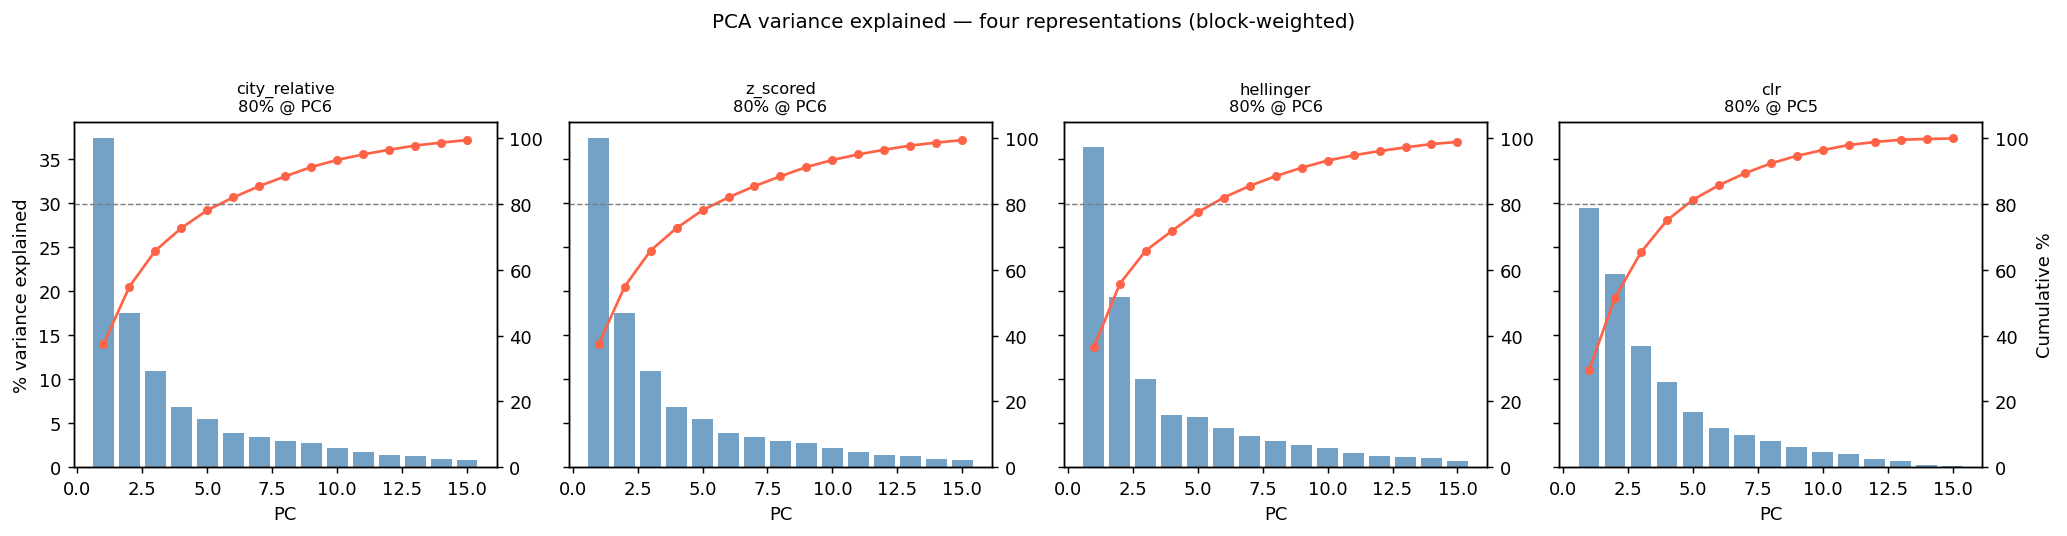

In [8]:
# PCA variance explained — compare representations
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
n_reps = len(representations)

for i, (name, X) in enumerate(representations.items()):
    ax = axes[i]
    pca = PCA(n_components=min(15, X.shape[1]))
    pca.fit(X)
    evr   = pca.explained_variance_ratio_
    cumev = np.cumsum(evr)
    n80   = int(np.searchsorted(cumev, 0.80)) + 1

    ax.bar(range(1, len(evr)+1), evr * 100, color="steelblue", alpha=0.75)
    ax2 = ax.twinx()
    ax2.plot(range(1, len(cumev)+1), cumev * 100, "o-", color="tomato", ms=4, lw=1.5)
    ax2.axhline(80, color="gray", ls="--", lw=0.8)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Cumulative %" if i == n_reps - 1 else "")
    ax.set_title(f"{name}\n80% @ PC{n80}", fontsize=9)
    ax.set_xlabel("PC")
    ax.set_ylabel("% variance explained" if i == 0 else "")

fig.suptitle("PCA variance explained — four representations (block-weighted)", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_variance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** After block weighting, CLR concentrates variance most aggressively (fewest components
needed for 80%); Hellinger is similar. City-relative deviations and z-scored land between them.

For the main analysis we use **city-relative deviations** because:
- Results are directly readable as pp over/under-performance vs the city
- The SF Chronicle used the same framing
- PCA handles any residual collinearity from the simplex constraint

Note: after block weighting applies `StandardScaler` within each block, city-relative and raw
shares become mathematically equivalent for clustering — the constant shift (citywide mean) is
absorbed by standardisation. The distinction matters for interpretability in the profile plots
(§8), where we always report raw pp deviations from citywide.

## 3. Dimensionality Reduction

**PCA** is the primary reduction step for clustering. It is deterministic, globally
distance-preserving, and produces a compact representation with interpretable loadings.
We retain enough components to explain ≥90% of variance.

**UMAP** is computed here as a **visualisation layer only**. It provides an intuitive 2-D
picture of cluster separation but is not used for clustering — UMAP embeddings are not globally
distance-preserving and K-means in 2-D UMAP space can fragment or merge clusters in misleading ways.

In [9]:
# PCA: retain components for ≥90% variance in the block-weighted city-relative space
pca_full = PCA(n_components=min(15, len(ALL_COLS)))
pca_full.fit(X_rel_w)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
print(f"PCA: {n90} components explain ≥90% of variance (block-weighted city-relative)")

pca = PCA(n_components=n90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_rel_w)
print(f"PCA output shape: {X_pca.shape}")

PCA: 9 components explain ≥90% of variance (block-weighted city-relative)
PCA output shape: (585, 9)


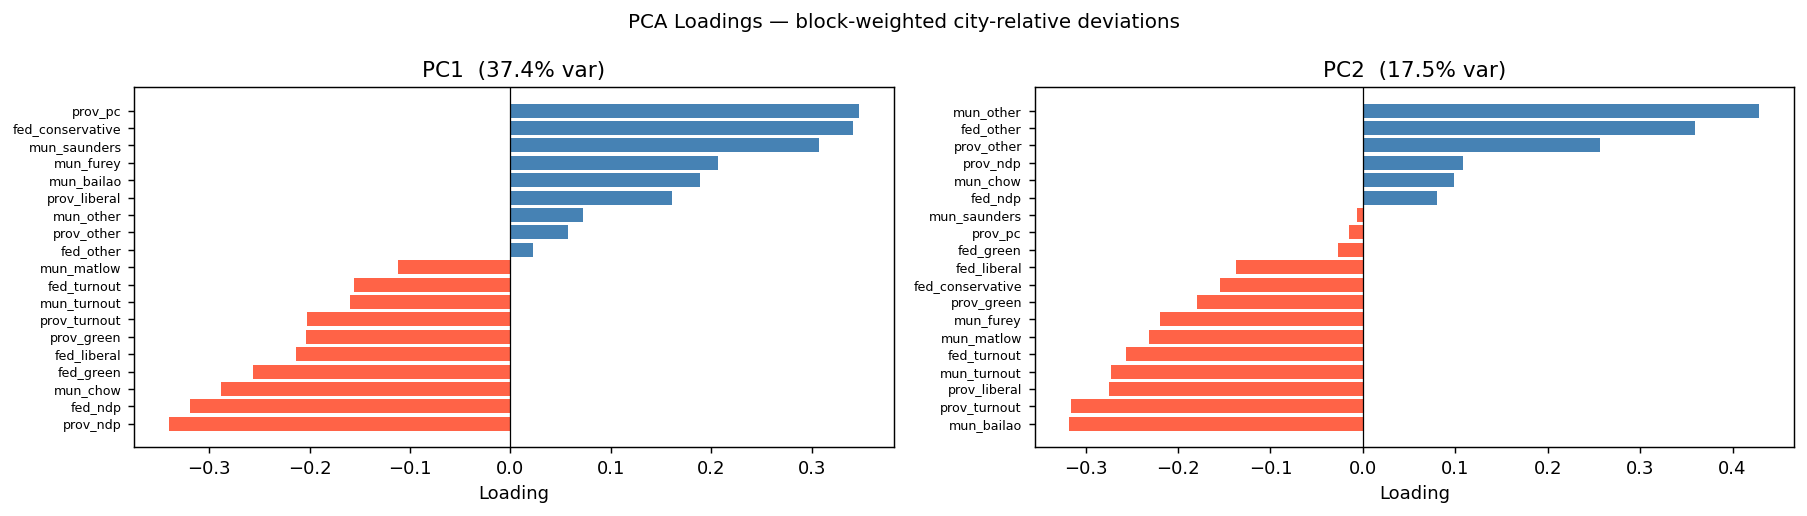

In [10]:
# PCA loading plot — top 2 PCs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for pc_idx, ax in enumerate(axes):
    loadings = pd.Series(pca.components_[pc_idx], index=ALL_COLS).sort_values()
    colors = ["tomato" if v < 0 else "steelblue" for v in loadings]
    ax.barh(range(len(loadings)), loadings.values, color=colors)
    ax.set_yticks(range(len(loadings)))
    ax.set_yticklabels(loadings.index, fontsize=7)
    ax.axvline(0, color="black", lw=0.7)
    ax.set_title(f"PC{pc_idx+1}  ({pca.explained_variance_ratio_[pc_idx]*100:.1f}% var)")
    ax.set_xlabel("Loading")

fig.suptitle("PCA Loadings — block-weighted city-relative deviations", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

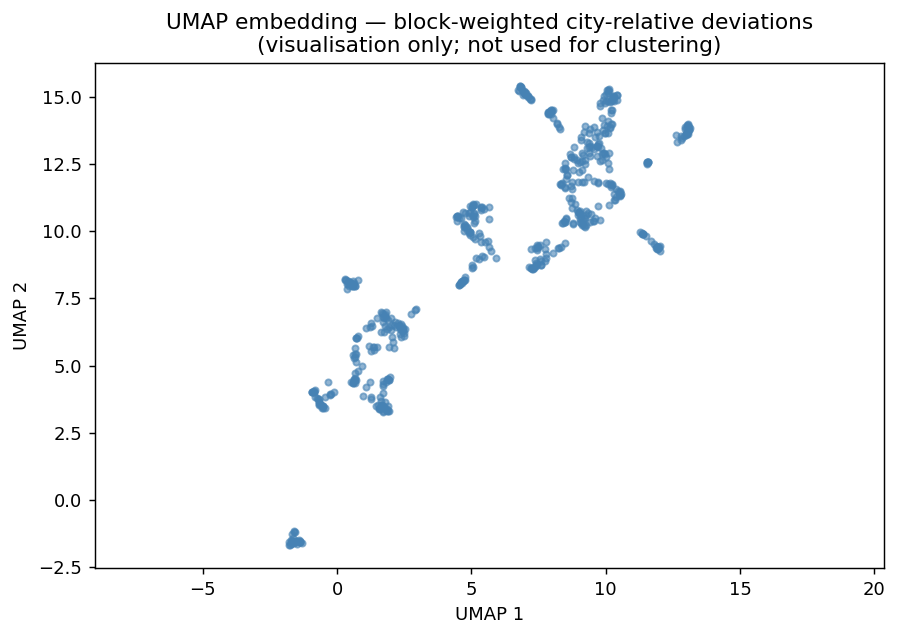

In [11]:
# UMAP: 2-D visualisation layer (not used for clustering)
# n_neighbors=20 balances local/global structure for ~585 points
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
X_umap = reducer.fit_transform(X_rel_w)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c="steelblue", s=12, alpha=0.6)
ax.set_title("UMAP embedding — block-weighted city-relative deviations\n(visualisation only; not used for clustering)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

## 4. Clustering in PCA Space

We cluster directly in PCA space (all {n90} components, ≥90% variance) rather than in UMAP 2-D.
PCA distances are globally meaningful; K-means in the full PCA space avoids the distortions
introduced by UMAP's non-linear manifold.

We compare **K-means** and **Ward hierarchical** clustering for k = 4–7 and use the silhouette
score to guide the choice of k.

Clustering (PCA space):   0%|          | 0/4 [00:00<?, ?it/s]

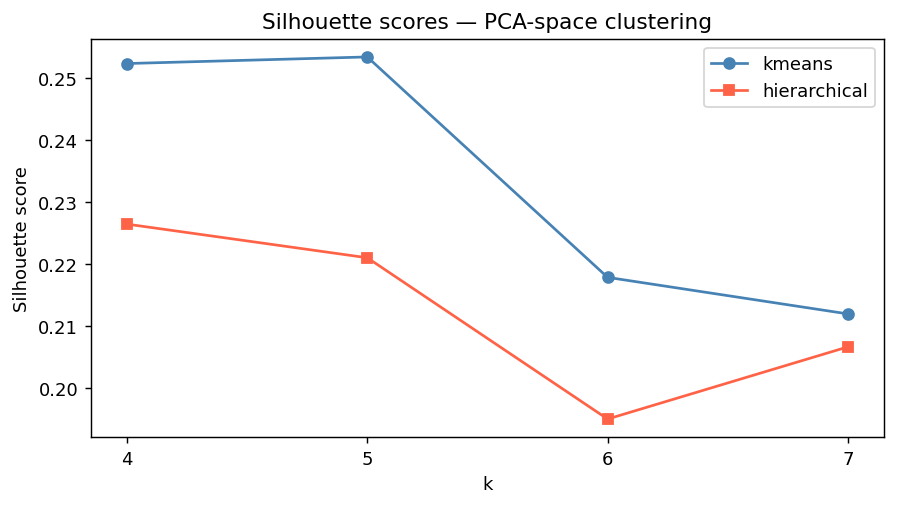

k=4: K-means=0.2524, Ward=0.2264
k=5: K-means=0.2535, Ward=0.2210
k=6: K-means=0.2178, Ward=0.1949
k=7: K-means=0.2119, Ward=0.2066


In [12]:
results_pca = {}
normal_idx = np.where(~anomaly_mask)[0]
X_pca_normal = X_pca[normal_idx]

def _assign_all(km, X_full, normal_idx, anomaly_mask):
    """Full label array: K-means labels for normal CTs, nearest centroid for anomalies."""
    labels = np.empty(len(X_full), dtype=int)
    labels[normal_idx] = km.labels_
    for i in np.where(anomaly_mask)[0]:
        labels[i] = np.argmin(np.linalg.norm(km.cluster_centers_ - X_full[i], axis=1))
    return labels

for k in tqdm(N_CLUSTERS_RANGE, desc="Clustering (PCA space)"):
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    km.fit(X_pca_normal)
    km_labels = _assign_all(km, X_pca, normal_idx, anomaly_mask)
    km_sil    = silhouette_score(X_pca_normal, km.labels_)  # score on normal CTs only

    Z = linkage(X_pca_normal, method="ward")
    hier_normal = fcluster(Z, t=k, criterion="maxclust") - 1
    hier_sil    = silhouette_score(X_pca_normal, hier_normal)
    # Expand hier labels to all CTs (anomalies nearest to centroid of each hier cluster)
    hier_cents  = np.array([X_pca_normal[hier_normal == c].mean(axis=0)
                             for c in range(k)])
    hier_labels = np.empty(len(X_pca), dtype=int)
    hier_labels[normal_idx] = hier_normal
    for i in np.where(anomaly_mask)[0]:
        hier_labels[i] = np.argmin(np.linalg.norm(hier_cents - X_pca[i], axis=1))

    results_pca[k] = {
        "kmeans":       (km_labels, km_sil),
        "hierarchical": (hier_labels, hier_sil),
    }

fig, ax = plt.subplots(figsize=(7, 4))
for method, marker, color in [("kmeans", "o", "steelblue"), ("hierarchical", "s", "tomato")]:
    sils = [results_pca[k][method][1] for k in N_CLUSTERS_RANGE]
    ax.plot(N_CLUSTERS_RANGE, sils, marker=marker, color=color, label=method, ms=6)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette score")
ax.set_xticks(N_CLUSTERS_RANGE)
ax.set_title("Silhouette scores — PCA-space clustering")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()

for k in N_CLUSTERS_RANGE:
    km_sil   = results_pca[k]["kmeans"][1]
    hier_sil = results_pca[k]["hierarchical"][1]
    print(f"k={k}: K-means={km_sil:.4f}, Ward={hier_sil:.4f}")

In [13]:
# ── Apply K_CHOSEN ────────────────────────────────────────────────────────────
# Update K_CHOSEN in the constants cell above, then re-run from here.

km_labels   = results_pca[K_CHOSEN]["kmeans"][0]
hier_labels = results_pca[K_CHOSEN]["hierarchical"][0]

# Reorder cluster IDs by geographic centroid longitude (west → east) for stable labelling
centroid_x = np.array([
    raw_gdf.geometry.centroid.x.values[km_labels == c].mean()
    for c in range(K_CHOSEN)
])
order = np.argsort(centroid_x)
remap = {old: new for new, old in enumerate(order)}
km_labels_sorted   = np.array([remap[l] for l in km_labels])
hier_labels_sorted = hier_labels   # leave hierarchical as-is for comparison

raw_gdf["cluster"]      = km_labels_sorted
raw_gdf["cluster_hier"] = hier_labels_sorted
rel_gdf["cluster"]      = km_labels_sorted

raw_gdf.to_file(PROFILES_DIR / "clustered_tracts.gpkg", driver="GPKG", layer="clustered")
print(f"Saved clustered_tracts.gpkg  (k={K_CHOSEN} K-means clusters)")

sizes = pd.Series(km_labels_sorted).value_counts().sort_index()
print("\nCluster sizes (K-means, PCA space):")
print(sizes.to_string())

Saved clustered_tracts.gpkg  (k=5 K-means clusters)

Cluster sizes (K-means, PCA space):
0    165
1     28
2    132
3    145
4    115


In [14]:
# K-means vs Ward hierarchical agreement
ari = adjusted_rand_score(km_labels_sorted, hier_labels_sorted)
print(f"Adjusted Rand Index (K-means vs Ward, k={K_CHOSEN}): {ari:.3f}")
print("  (1.0 = identical, 0 = random)")

pd.crosstab(
    pd.Series(km_labels_sorted, name="K-means"),
    pd.Series(hier_labels_sorted, name="Hierarchical"),
)

Adjusted Rand Index (K-means vs Ward, k=5): 0.639
  (1.0 = identical, 0 = random)


Hierarchical,0,1,2,3,4
K-means,,,,,
0,149,4,0,12,0
1,0,0,0,27,1
2,0,0,0,5,127
3,19,9,117,0,0
4,5,49,2,22,37


## 5. Sensitivity Analysis

Each variant changes exactly one dimension from the base configuration
(city-relative deviations, block-weighted, PCA clustering, k=5, all features).
For variants with the same k, we report the Adjusted Rand Index (ARI) against the base
to quantify how much the assignments change.

| Variant | What changes |
|---|---|
| No turnout | Drop the 3 turnout columns |
| No 'other' bucket | Drop mun_other, prov_other, fed_other |
| Hellinger transform | √(share) instead of city-relative deviations |
| CLR transform | Centred log-ratio; statistically correct for the simplex |
| k = 4 | One fewer cluster |
| k = 6 | One more cluster |
| UMAP clustering | K-means in UMAP 2-D instead of PCA (previous approach) |

**Note on raw shares vs city-relative:** After block weighting applies `StandardScaler`
within each block, the centring step absorbs the citywide mean, making raw shares and
city-relative representations mathematically identical for clustering. The distinction
is only meaningful for profile plots (§8).

In [15]:
def cluster_in_pca(X, col_names, blocks, k, var_threshold=0.90):
    """Block-weight → PCA → K-means (excluding anomalous CTs from fitting).
    Returns (full_labels, silhouette_on_normal_CTs)."""
    X_w = apply_block_weights(X, col_names, blocks)
    pf  = PCA(n_components=min(15, X_w.shape[1])); pf.fit(X_w)
    n_c = min(int(np.searchsorted(np.cumsum(pf.explained_variance_ratio_), var_threshold)) + 1,
              X_w.shape[1])
    X_emb    = PCA(n_components=n_c, random_state=RANDOM_STATE).fit_transform(X_w)
    norm_idx = np.where(~anomaly_mask)[0]
    km       = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    km.fit(X_emb[norm_idx])
    labels_all = _assign_all(km, X_emb, norm_idx, anomaly_mask)
    return labels_all, silhouette_score(X_emb[norm_idx], km.labels_)

# ── Blocks for feature-exclusion variants ────────────────────────────────────
NO_TURN_COLS  = [c for c in ALL_COLS if "turnout" not in c]
BLOCKS_NO_TURN = {
    "municipal":  [c for c in ELECTION_BLOCKS["municipal"]  if "turnout" not in c],
    "provincial": [c for c in ELECTION_BLOCKS["provincial"] if "turnout" not in c],
    "federal":    [c for c in ELECTION_BLOCKS["federal"]    if "turnout" not in c],
}
NO_OTHER_COLS  = [c for c in ALL_COLS if "other" not in c]
BLOCKS_NO_OTHER = {
    "municipal":  [c for c in ELECTION_BLOCKS["municipal"]  if "other" not in c],
    "provincial": [c for c in ELECTION_BLOCKS["provincial"] if "other" not in c],
    "federal":    [c for c in ELECTION_BLOCKS["federal"]    if "other" not in c],
}

X_rel_no_turn  = X_rel[:, [ALL_COLS.index(c) for c in NO_TURN_COLS]]
X_rel_no_other = X_rel[:, [ALL_COLS.index(c) for c in NO_OTHER_COLS]]

# UMAP clustering: K-means in the already-computed X_umap (same block-weighted input)
_norm = np.where(~anomaly_mask)[0]
km_umap = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
km_umap.fit(X_umap[_norm])
umap_labels = _assign_all(km_umap, X_umap, _norm, anomaly_mask)
umap_sil    = silhouette_score(X_umap[_norm], km_umap.labels_)
umap_ari    = adjusted_rand_score(km_labels_sorted, umap_labels)

# ── Run all variants ──────────────────────────────────────────────────────────
sensitivity_variants = [
    ("Base (city-relative, k=5, PCA)",  X_rel,          ALL_COLS,       ELECTION_BLOCKS, K_CHOSEN),
    ("No turnout",                       X_rel_no_turn,  NO_TURN_COLS,   BLOCKS_NO_TURN,  K_CHOSEN),
    ("No 'other' bucket",                X_rel_no_other, NO_OTHER_COLS,  BLOCKS_NO_OTHER, K_CHOSEN),
    ("Hellinger transform",              X_hell,         ALL_COLS,       ELECTION_BLOCKS, K_CHOSEN),
    ("CLR transform",                    X_clr,          ALL_COLS,       ELECTION_BLOCKS, K_CHOSEN),
    ("k = 4",                            X_rel,          ALL_COLS,       ELECTION_BLOCKS, 4),
    ("k = 6",                            X_rel,          ALL_COLS,       ELECTION_BLOCKS, 6),
]

rows = []
print(f"{'Variant':<38} {'k':>2}  {'Silhouette':>10}  {'ARI vs base':>11}")
print("-" * 68)
for name, X, cols, blocks, k in sensitivity_variants:
    labels, sil = cluster_in_pca(X, cols, blocks, k)
    ari = adjusted_rand_score(km_labels_sorted, labels) if k == K_CHOSEN else float("nan")
    ari_str = f"{ari:.3f}" if not np.isnan(ari) else "—"
    print(f"{name:<38} {k:>2}  {sil:>10.4f}  {ari_str:>11}")
    rows.append({"Variant": name, "k": k, "Silhouette": round(sil, 4),
                 "ARI vs base": ari_str})

# UMAP clustering row
print(f"{'UMAP clustering':<38} {K_CHOSEN:>2}  {umap_sil:>10.4f}  {umap_ari:>11.3f}")
rows.append({"Variant": "UMAP clustering", "k": K_CHOSEN,
             "Silhouette": round(umap_sil, 4), "ARI vs base": f"{umap_ari:.3f}"})

sensitivity_df = pd.DataFrame(rows)
sensitivity_df.to_csv(EXPLORE_DIR / "sensitivity_summary.csv", index=False)
print("\nSaved sensitivity_summary.csv to explore/")

Variant                                 k  Silhouette  ARI vs base
--------------------------------------------------------------------
Base (city-relative, k=5, PCA)          5      0.2535        1.000


No turnout                              5      0.2932        0.742


No 'other' bucket                       5      0.2530        0.933


Hellinger transform                     5      0.2476        0.649


CLR transform                           5      0.3663        0.315


k = 4                                   4      0.2524            —


k = 6                                   6      0.2178            —
UMAP clustering                         5      0.4989        0.497

Saved sensitivity_summary.csv to explore/


## 6. Riding-Level Analysis

Provincial and federal elections are contested at the riding level. Two census tracts with
identical underlying political preferences could vote very differently because of candidate
quality, incumbent effects, and strategic voting dynamics within their riding.

To test how much of the cluster structure is driven by riding-level effects vs genuine
neighbourhood character, we compute **within-riding residuals**: for each feature, we subtract
the mean of all tracts in the same riding, leaving only the variation *within* a riding.
We then cluster these residuals using the same PCA pipeline.

**Riding assignment:**
- **Municipal features** → Toronto wards (derived from 2023 polling subdivision boundaries)
  — used as the sub-city unit for a city-wide mayoral race; no within-race riding effect,
  but wards capture local political organisation
- **Provincial features** → Ontario 2025 provincial electoral ridings (25 Toronto ridings)
- **Federal features** → Canada 2025 federal electoral ridings (24 Toronto ridings)

If the riding-residual clusters resemble the main clusters (high ARI), riding effects are
**not** the primary driver. If ARI is near zero, the main clusters are largely a
riding-level phenomenon.

In [16]:
# ── Load geographic boundaries ────────────────────────────────────────────────
# Ward polygons: dissolve 2023 polling subdivisions on the first 2 digits of AREA_LONG_CODE
subdiv_gdf = gpd.read_file(RIDING_DIR / "toronto_2023_subdivisions.geojson")
subdiv_gdf["ward"] = subdiv_gdf["AREA_LONG_CODE"].str[:2].astype(str)
ward_gdf   = subdiv_gdf.dissolve(by="ward")

prov_ridings = gpd.read_file(RIDING_DIR / "ont_2025_ridings.geojson")
fed_ridings  = gpd.read_file(RIDING_DIR / "fed_2025_ridings.geojson")

print(f"Ward polygons: {len(ward_gdf)}")
print(f"Provincial ridings (full file): {len(prov_ridings)}")
print(f"Federal ridings (full file):    {len(fed_ridings)}")

# ── Assign each CT to its riding via centroid spatial join ───────────────────
def assign_ridings(ct_gdf, ward_gdf, prov_ridings, fed_ridings):
    """Return a DataFrame with columns [ct_id, mun_riding, prov_riding, fed_riding].
    Falls back to nearest polygon for any centroid that misses its riding."""
    centroids_gdf = gpd.GeoDataFrame(
        {"ct_id": ct_gdf["ct_id"].values},
        geometry=ct_gdf.geometry.centroid.values,
        crs=ct_gdf.crs,
    )
    bbox = shapely_box(*ct_gdf.total_bounds)
    prov_local = prov_ridings[prov_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    fed_local  = fed_ridings[fed_ridings.geometry.intersects(bbox)][["RIDINGNAME",  "geometry"]].reset_index(drop=True)
    ward_local = ward_gdf.reset_index()[["ward", "geometry"]].copy()

    def sjoin_with_fallback(pts, polys, id_col, out_col):
        joined = gpd.sjoin(pts, polys[[id_col, "geometry"]], how="left", predicate="within")
        joined = joined.drop_duplicates("ct_id")[["ct_id", id_col]]
        missing_mask = joined[id_col].isna()
        if missing_mask.any():
            for _, row in joined[missing_mask].iterrows():
                pt = pts.loc[pts["ct_id"] == row["ct_id"], "geometry"].values[0]
                nearest = polys.geometry.distance(pt).idxmin()
                joined.loc[joined["ct_id"] == row["ct_id"], id_col] = polys.loc[nearest, id_col]
        return joined.rename(columns={id_col: out_col})

    ward_j = sjoin_with_fallback(centroids_gdf, ward_local, "ward",      "mun_riding")
    prov_j = sjoin_with_fallback(centroids_gdf, prov_local, "RIDINGNAME","prov_riding")
    fed_j  = sjoin_with_fallback(centroids_gdf, fed_local,  "RIDINGNAME","fed_riding")

    return ward_j.merge(prov_j, on="ct_id").merge(fed_j, on="ct_id")

riding_df = assign_ridings(raw_gdf, ward_gdf, prov_ridings, fed_ridings)
print(f"\nCTs assigned: {len(riding_df)}")
print(f"  Wards: {riding_df['mun_riding'].nunique()} | "
      f"Prov ridings: {riding_df['prov_riding'].nunique()} | "
      f"Fed ridings: {riding_df['fed_riding'].nunique()}")
print(f"  Missing: mun={riding_df['mun_riding'].isna().sum()}, "
      f"prov={riding_df['prov_riding'].isna().sum()}, "
      f"fed={riding_df['fed_riding'].isna().sum()}")

Ward polygons: 25
Provincial ridings (full file): 124
Federal ridings (full file):    343

CTs assigned: 585
  Wards: 25 | Prov ridings: 25 | Fed ridings: 24
  Missing: mun=0, prov=0, fed=0


In [17]:
# ── Compute within-riding residuals ──────────────────────────────────────────
MUN_COLS  = ["mun_turnout"]  + MUN_SHARE_COLS
PROV_COLS = ["prov_turnout"] + PROV_SHARE_COLS
FED_COLS  = ["fed_turnout"]  + FED_SHARE_COLS

def compute_riding_residuals(raw_gdf, riding_df, mun_cols, prov_cols, fed_cols):
    """Subtract the within-riding mean from each CT's features.
    Each election level uses its own geographic unit."""
    df = raw_gdf[mun_cols + prov_cols + fed_cols].copy()
    df.index = raw_gdf["ct_id"]
    df = df.join(riding_df.set_index("ct_id"))

    mun_means  = df.groupby("mun_riding")[mun_cols].transform("mean")
    prov_means = df.groupby("prov_riding")[prov_cols].transform("mean")
    fed_means  = df.groupby("fed_riding")[fed_cols].transform("mean")

    res = pd.DataFrame(index=df.index)
    res[mun_cols]  = df[mun_cols].values  - mun_means.values
    res[prov_cols] = df[prov_cols].values - prov_means.values
    res[fed_cols]  = df[fed_cols].values  - fed_means.values
    return res

resid_df = compute_riding_residuals(raw_gdf, riding_df, MUN_COLS, PROV_COLS, FED_COLS)

# Sanity check: column means should be ~0
print("Within-riding residual column means (should be ~0):")
print(resid_df.mean().round(8).to_string())

Within-riding residual column means (should be ~0):
mun_turnout         0.0
mun_chow            0.0
mun_bailao         -0.0
mun_saunders        0.0
mun_furey          -0.0
mun_matlow          0.0
mun_other           0.0
prov_turnout       -0.0
prov_pc             0.0
prov_ndp           -0.0
prov_liberal       -0.0
prov_green          0.0
prov_other         -0.0
fed_turnout         0.0
fed_liberal         0.0
fed_conservative    0.0
fed_ndp             0.0
fed_green          -0.0
fed_other           0.0


In [18]:
# ── Cluster the within-riding residuals ──────────────────────────────────────
X_resid = resid_df[ALL_COLS].values.astype(float)
X_resid_w = apply_block_weights(X_resid, ALL_COLS, ELECTION_BLOCKS)

pca_resid_full = PCA(n_components=min(15, X_resid_w.shape[1]))
pca_resid_full.fit(X_resid_w)
n90_resid = int(np.searchsorted(np.cumsum(pca_resid_full.explained_variance_ratio_), 0.90)) + 1
X_pca_resid = PCA(n_components=n90_resid, random_state=RANDOM_STATE).fit_transform(X_resid_w)

_norm_r  = np.where(~anomaly_mask)[0]
km_resid = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
km_resid.fit(X_pca_resid[_norm_r])
resid_labels = _assign_all(km_resid, X_pca_resid, _norm_r, anomaly_mask)
resid_sil    = silhouette_score(X_pca_resid[_norm_r], km_resid.labels_)
resid_ari    = adjusted_rand_score(km_labels_sorted, resid_labels)

print(f"Within-riding residual clustering (k={K_CHOSEN}):")
print(f"  Silhouette score: {resid_sil:.4f}  (main: {results_pca[K_CHOSEN]['kmeans'][1]:.4f})")
print(f"  ARI vs main clusters: {resid_ari:.4f}")
print()
print("ARI interpretation:")
print("  Near 1.0 → riding effects are NOT the primary driver; neighbourhood character dominates")
print("  Near 0.0 → main clusters are largely a riding-level phenomenon")
print()

# Save residual cluster assignments for mapping
raw_gdf["cluster_resid"] = resid_labels
raw_gdf.to_file(EXPLORE_DIR / "clustered_tracts_riding_residual.gpkg", driver="GPKG", layer="residual")
print("Saved clustered_tracts_riding_residual.gpkg to explore/")

Within-riding residual clustering (k=5):
  Silhouette score: 0.1271  (main: 0.2535)
  ARI vs main clusters: 0.1115

ARI interpretation:
  Near 1.0 → riding effects are NOT the primary driver; neighbourhood character dominates
  Near 0.0 → main clusters are largely a riding-level phenomenon



Saved clustered_tracts_riding_residual.gpkg to explore/


## 7. Visualisations

Three views of the clustering:
1. **Geographic map** — where each political group lives in the city
2. **UMAP scatter** — how separated the groups are in political space (clusters coloured by the PCA K-means labels)
3. **Riding-residual comparison** — main clusters vs within-riding-residual clusters side by side

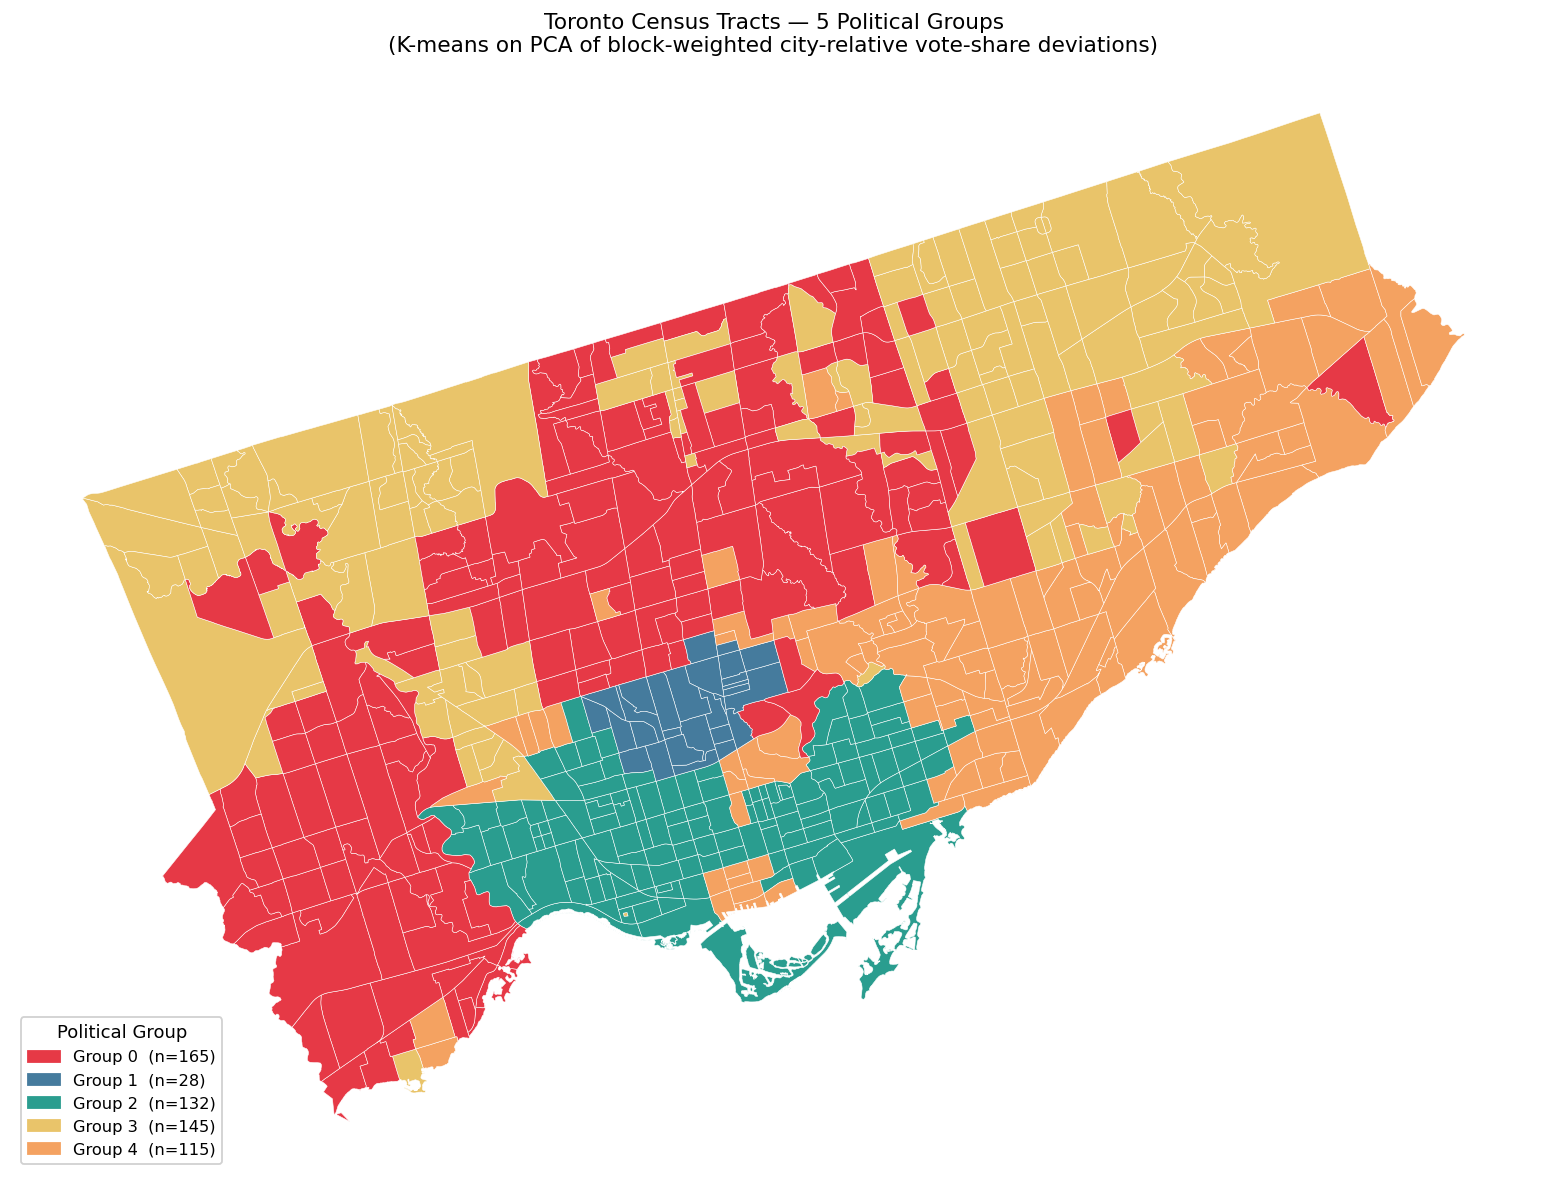

In [19]:
cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])

fig, ax = plt.subplots(figsize=(12, 13))
raw_gdf.plot(
    column="cluster", ax=ax, categorical=True,
    cmap=cmap, edgecolor="white", linewidth=0.3, legend=False,
)
patches = [
    mpatches.Patch(color=PALETTE[c], label=f"Group {c}  (n={sizes[c]})")
    for c in range(K_CHOSEN)
]
ax.legend(handles=patches, loc="lower left", title="Political Group",
          framealpha=0.9, fontsize=9)
ax.set_title(
    f"Toronto Census Tracts — {K_CHOSEN} Political Groups\n"
    "(K-means on PCA of block-weighted city-relative vote-share deviations)",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_map.png", dpi=200, bbox_inches="tight")
plt.show()

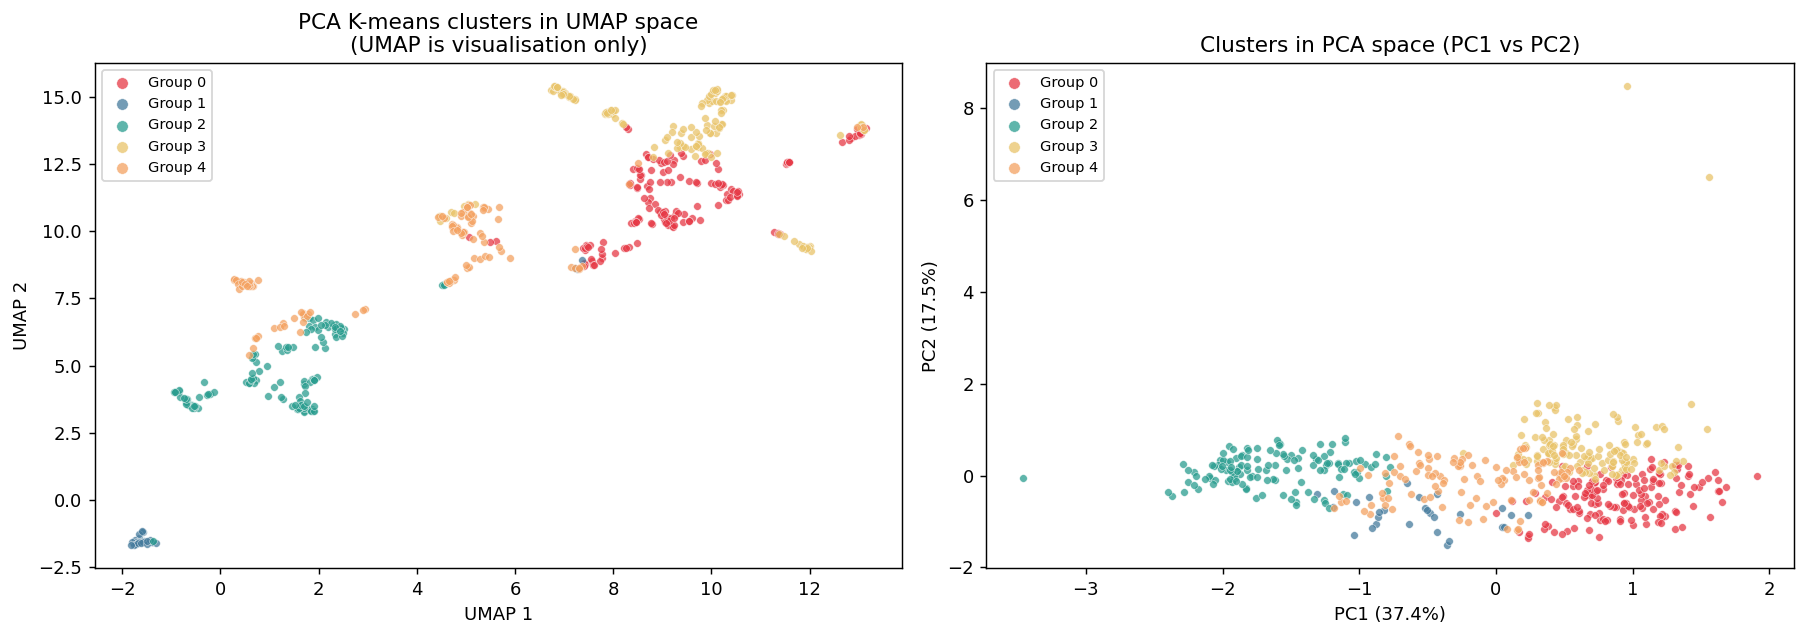

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PCA-derived clusters in UMAP space
for c in range(K_CHOSEN):
    mask = km_labels_sorted == c
    ax1.scatter(X_umap[mask, 0], X_umap[mask, 1],
                color=PALETTE[c], label=f"Group {c}",
                s=18, alpha=0.75, edgecolors="white", linewidths=0.3)
ax1.set_title("PCA K-means clusters in UMAP space\n(UMAP is visualisation only)")
ax1.set_xlabel("UMAP 1"); ax1.set_ylabel("UMAP 2")
ax1.legend(markerscale=1.5, fontsize=8)

# PCA scatter (PC1 vs PC2)
for c in range(K_CHOSEN):
    mask = km_labels_sorted == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=PALETTE[c], label=f"Group {c}",
                s=18, alpha=0.75, edgecolors="white", linewidths=0.3)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title("Clusters in PCA space (PC1 vs PC2)")
ax2.legend(markerscale=1.5, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "umap_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

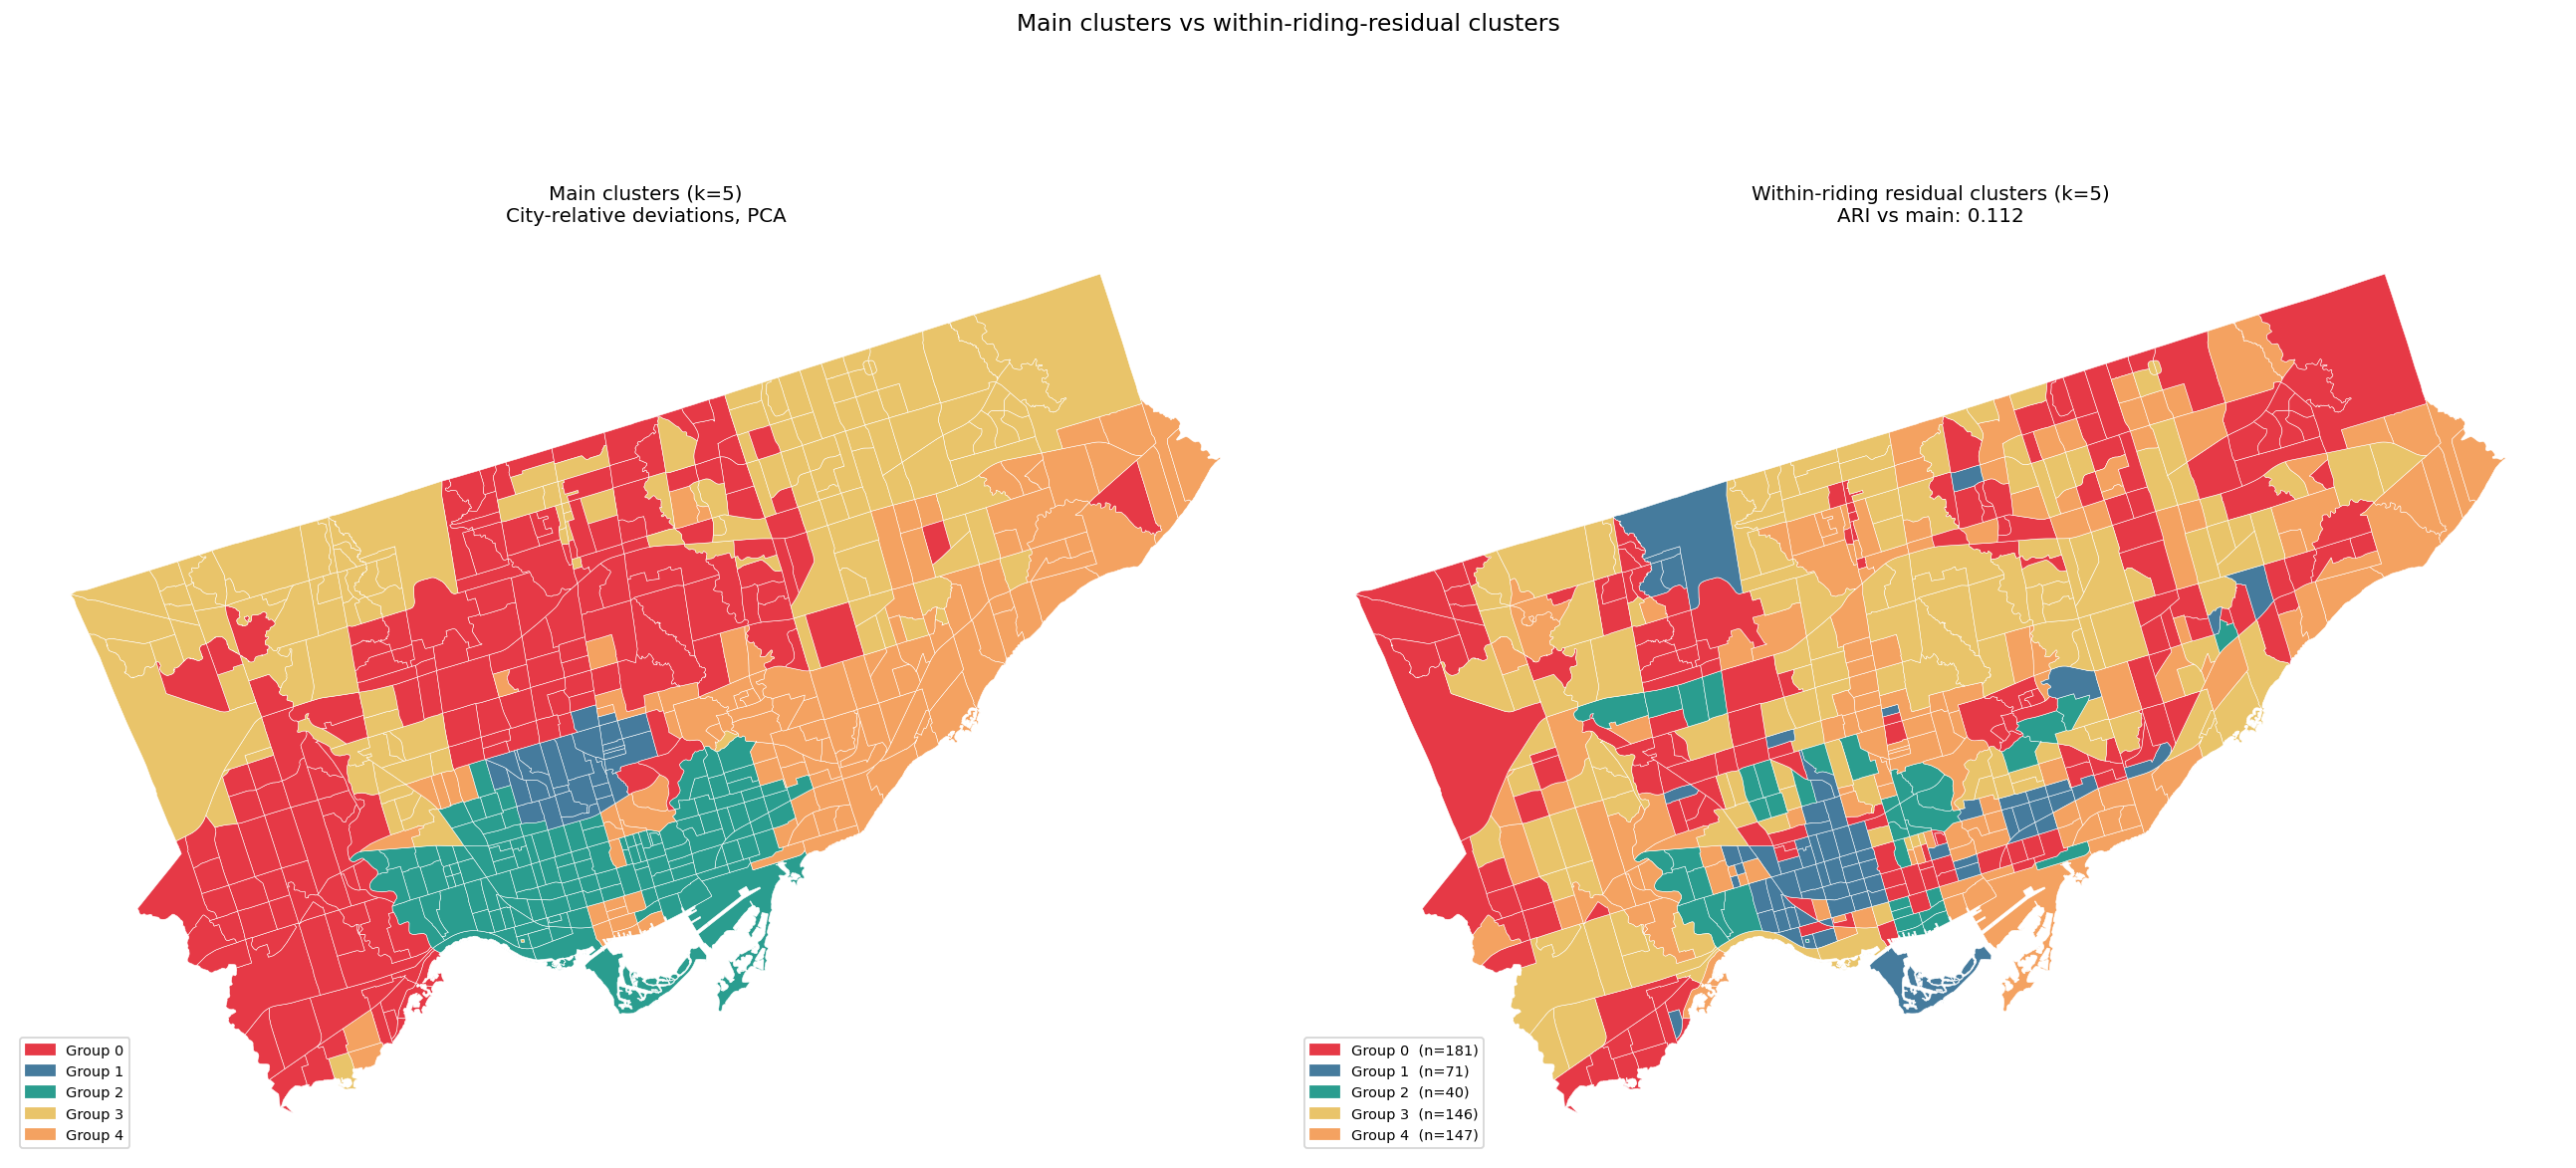

In [21]:
# Riding-residual comparison map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN})\nCity-relative deviations, PCA", fontsize=11)
ax1.axis("off")
patches = [mpatches.Patch(color=PALETTE[c], label=f"Group {c}") for c in range(K_CHOSEN)]
ax1.legend(handles=patches, loc="lower left", fontsize=8)

cmap_resid = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
raw_gdf.plot(column="cluster_resid", ax=ax2, categorical=True,
             cmap=cmap_resid, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(f"Within-riding residual clusters (k={K_CHOSEN})\nARI vs main: {resid_ari:.3f}", fontsize=11)
ax2.axis("off")
resid_sizes = pd.Series(resid_labels).value_counts().sort_index()
patches2 = [mpatches.Patch(color=PALETTE[c], label=f"Group {c}  (n={resid_sizes.get(c, 0)})") for c in range(K_CHOSEN)]
ax2.legend(handles=patches2, loc="lower left", fontsize=8)

fig.suptitle("Main clusters vs within-riding-residual clusters", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "cluster_map_riding_residual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Cluster Profiles

The heatmap shows each cluster's average **deviation from citywide** for every
party/candidate and turnout. Green = above city average; red = below.
Values are in percentage points.

These are computed from the *raw* city-relative deviations (not the block-weighted
PCA input), so they are directly interpretable.

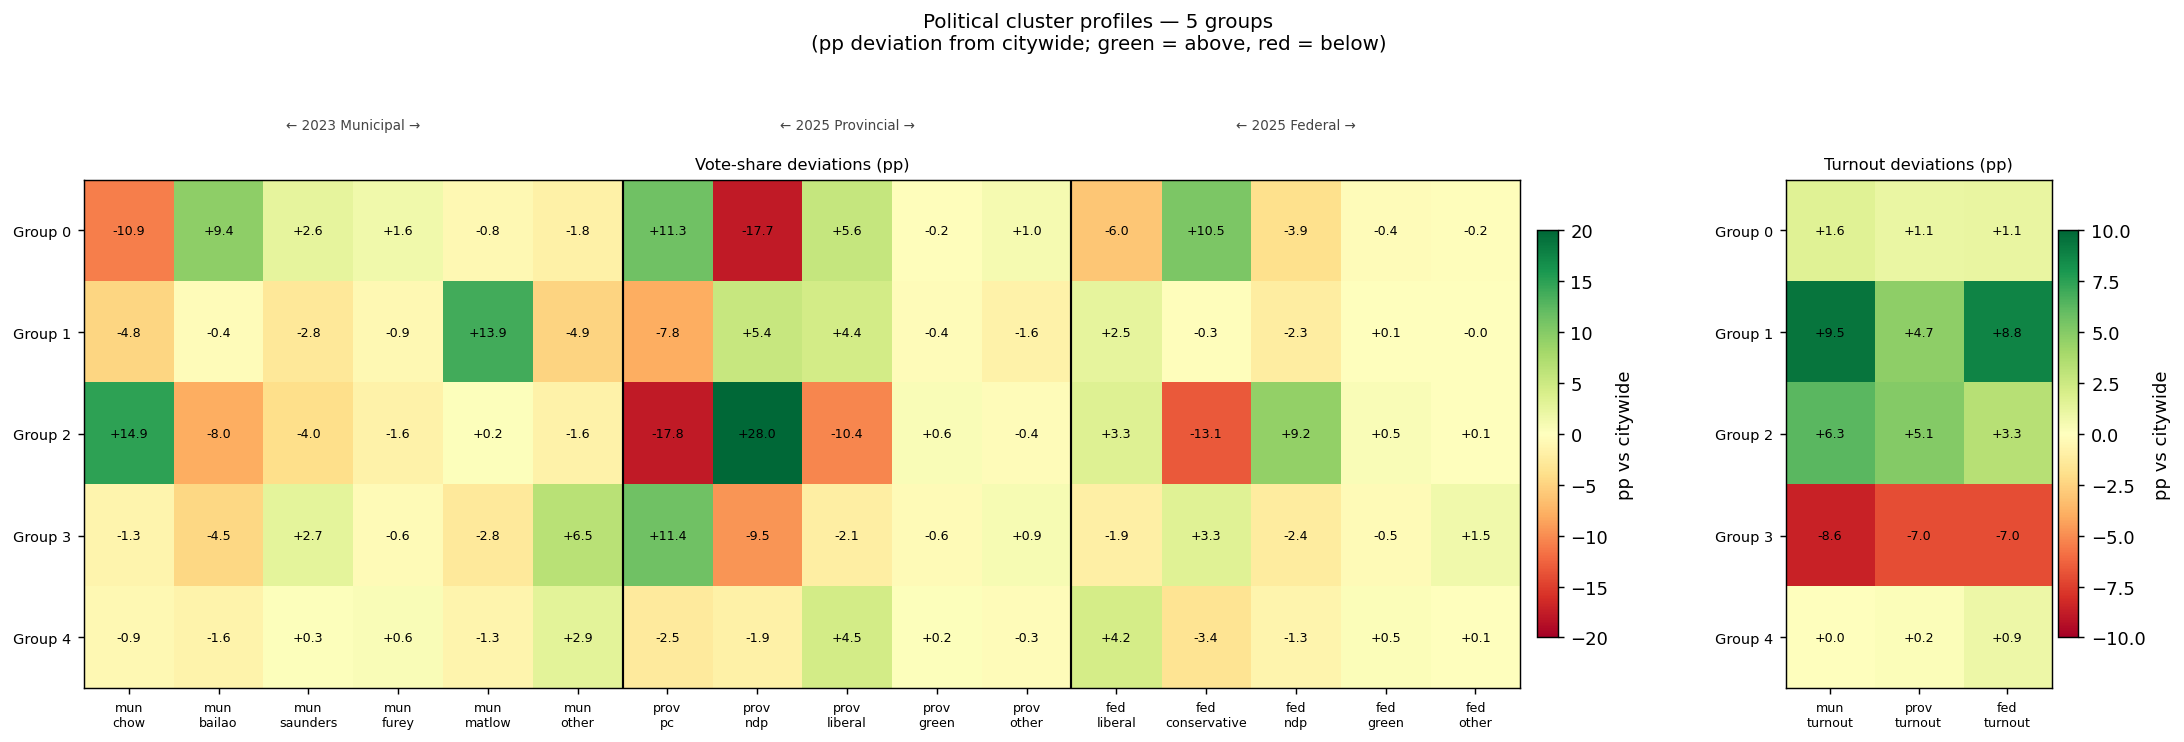

In [22]:
# Cluster-average pp deviations (raw city-relative, not block-weighted)
profile_rows = []
for c in range(K_CHOSEN):
    mask = km_labels_sorted == c
    row  = rel_df[ALL_COLS].values[mask].mean(axis=0)
    profile_rows.append(row)

profiles = pd.DataFrame(
    np.array(profile_rows) * 100,
    columns=ALL_COLS,
    index=[f"Group {c}" for c in range(K_CHOSEN)],
)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, (ax_shares, ax_turn) = plt.subplots(
    1, 2,
    figsize=(17, 3.5 + K_CHOSEN * 0.4),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]},
)

def draw_heatmap(ax, data, cols, title, vabs=20):
    im = ax.imshow(data[cols].values, cmap="RdYlGn",
                   aspect="auto", vmin=-vabs, vmax=vabs)
    for i in range(data.shape[0]):
        for j, col in enumerate(cols):
            val = data[col].iloc[i]
            ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                    fontsize=7, color="black")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=7, rotation=0)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_title(title, fontsize=9)
    return im

im1 = draw_heatmap(ax_shares, profiles, SHARE_COLS, "Vote-share deviations (pp)")
im2 = draw_heatmap(ax_turn,   profiles, TURNOUT_COLS, "Turnout deviations (pp)", vabs=10)

fig.colorbar(im1, ax=ax_shares, label="pp vs citywide", shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=ax_turn,   label="pp vs citywide", shrink=0.8, pad=0.02)

n_mun = len(MUN_SHARE_COLS); n_prov = len(PROV_SHARE_COLS)
for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
    ax_shares.axvline(x, color="black", lw=1.2)
for x, label in [
    (n_mun / 2 - 0.5,                              "← 2023 Municipal →"),
    (n_mun + n_prov / 2 - 0.5,                     "← 2025 Provincial →"),
    (n_mun + n_prov + len(FED_SHARE_COLS)/2 - 0.5, "← 2025 Federal →"),
]:
    ax_shares.text(x, -1.1, label, ha="center", va="top", fontsize=7.5, color="#444")

fig.suptitle(f"Political cluster profiles — {K_CHOSEN} groups\n"
             "(pp deviation from citywide; green = above, red = below)",
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_profiles_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
# Summary table
print(f"=== Cluster Summary (k={K_CHOSEN}) ===\n")
for c in range(K_CHOSEN):
    mask   = km_labels_sorted == c
    row    = profiles.loc[f"Group {c}", SHARE_COLS]
    t_dev  = profiles.loc[f"Group {c}", TURNOUT_COLS]
    top3_over  = row.nlargest(3)
    top3_under = row.nsmallest(3)
    print(f"Group {c}  ({mask.sum()} tracts)")
    print(f"  Turnout: " + ", ".join(f"{col.replace('_turnout','')}={v:+.1f}pp" for col, v in t_dev.items()))
    print(f"  Over:    " + ", ".join(f"{col}={v:+.1f}pp" for col, v in top3_over.items()))
    print(f"  Under:   " + ", ".join(f"{col}={v:+.1f}pp" for col, v in top3_under.items()))
    print()

=== Cluster Summary (k=5) ===

Group 0  (165 tracts)
  Turnout: mun=+1.6pp, prov=+1.1pp, fed=+1.1pp
  Over:    prov_pc=+11.3pp, fed_conservative=+10.5pp, mun_bailao=+9.4pp
  Under:   prov_ndp=-17.7pp, mun_chow=-10.9pp, fed_liberal=-6.0pp

Group 1  (28 tracts)
  Turnout: mun=+9.5pp, prov=+4.7pp, fed=+8.8pp
  Over:    mun_matlow=+13.9pp, prov_ndp=+5.4pp, prov_liberal=+4.4pp
  Under:   prov_pc=-7.8pp, mun_other=-4.9pp, mun_chow=-4.8pp

Group 2  (132 tracts)
  Turnout: mun=+6.3pp, prov=+5.1pp, fed=+3.3pp
  Over:    prov_ndp=+28.0pp, mun_chow=+14.9pp, fed_ndp=+9.2pp
  Under:   prov_pc=-17.8pp, fed_conservative=-13.1pp, prov_liberal=-10.4pp

Group 3  (145 tracts)
  Turnout: mun=-8.6pp, prov=-7.0pp, fed=-7.0pp
  Over:    prov_pc=+11.4pp, mun_other=+6.5pp, fed_conservative=+3.3pp
  Under:   prov_ndp=-9.5pp, mun_bailao=-4.5pp, mun_matlow=-2.8pp

Group 4  (115 tracts)
  Turnout: mun=+0.0pp, prov=+0.2pp, fed=+0.9pp
  Over:    prov_liberal=+4.5pp, fed_liberal=+4.2pp, mun_other=+2.9pp
  Under:   fe

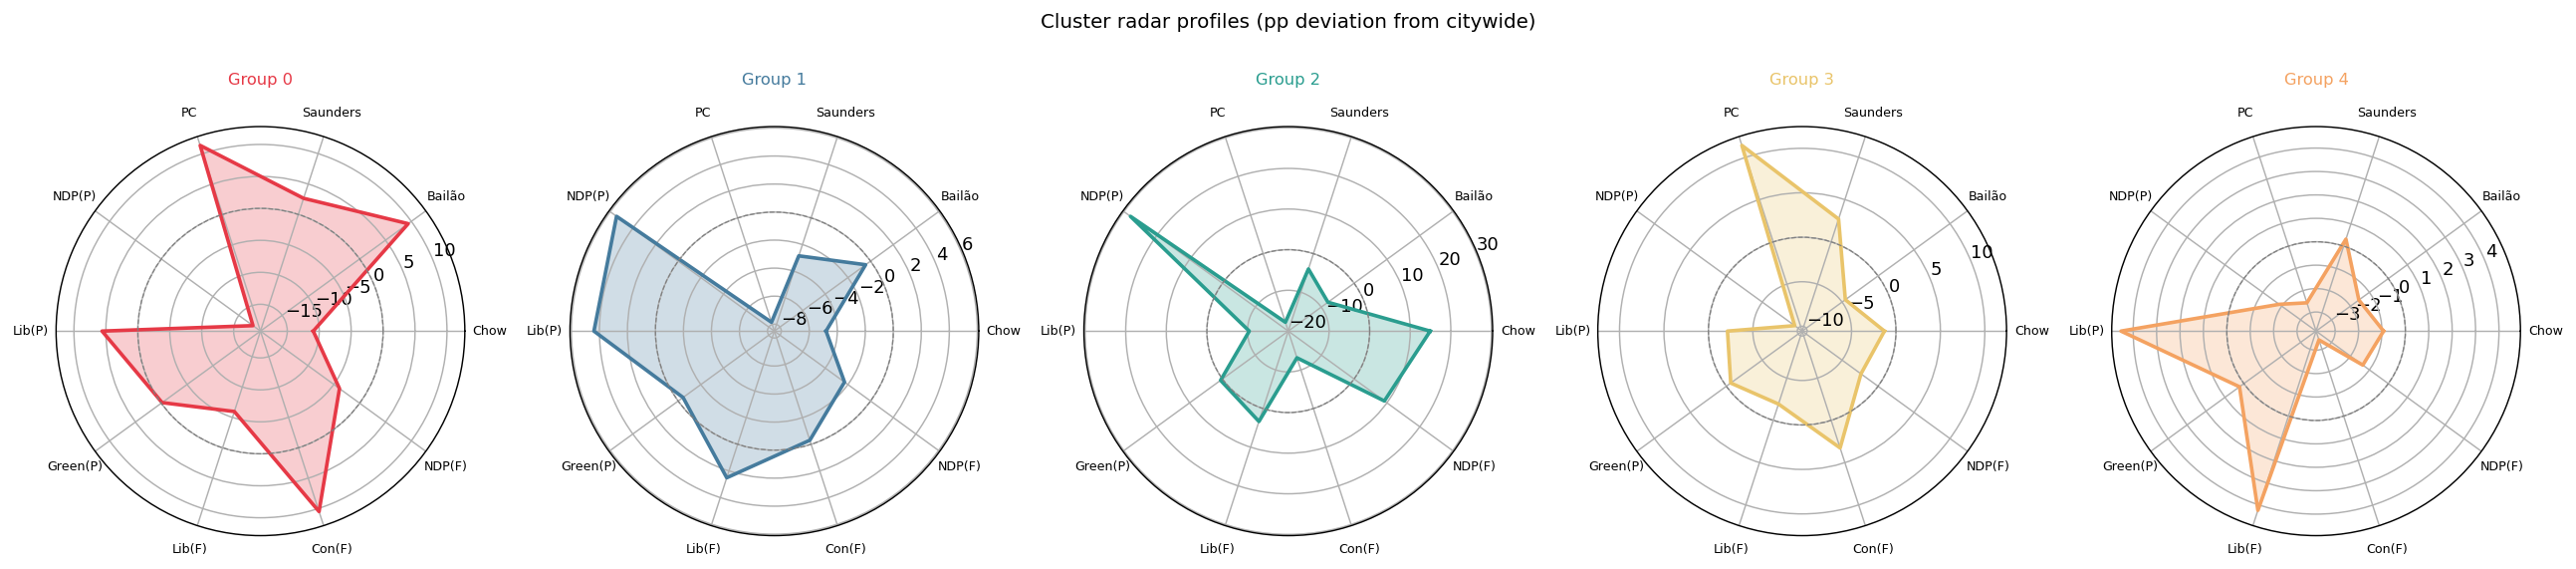

In [24]:
# Radar / spider charts
radar_cols = [
    "mun_chow", "mun_bailao", "mun_saunders",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green",
    "fed_liberal", "fed_conservative", "fed_ndp",
]
radar_labels = [
    "Chow", "Bailão", "Saunders",
    "PC", "NDP(P)", "Lib(P)", "Green(P)",
    "Lib(F)", "Con(F)", "NDP(F)",
]
N = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_CHOSEN, figsize=(4 * K_CHOSEN, 4.5),
                          subplot_kw={"polar": True})
if K_CHOSEN == 1: axes = [axes]

for c, ax in enumerate(axes):
    values = profiles.loc[f"Group {c}", radar_cols].values.tolist() + [profiles.loc[f"Group {c}", radar_cols].values[0]]
    ax.plot(angles, values, color=PALETTE[c], lw=2)
    ax.fill(angles, values, color=PALETTE[c], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7)
    ax.set_title(f"Group {c}", fontsize=9, pad=12, color=PALETTE[c])
    ax.axhline(0, color="gray", lw=0.7, ls="--")

fig.suptitle("Cluster radar profiles (pp deviation from citywide)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Export full profiles table to profiles/
profiles_out = profiles.copy()
profiles_out.insert(0, "n_tracts", [int((km_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
profiles_out.to_csv(PROFILES_DIR / "cluster_profiles.csv")
print("Saved cluster_profiles.csv to profiles/")
print()
print(profiles_out[["n_tracts"] + SHARE_COLS].round(1).to_string())

Saved cluster_profiles.csv to profiles/

         n_tracts  mun_chow  mun_bailao  mun_saunders  mun_furey  mun_matlow  mun_other  prov_pc  prov_ndp  prov_liberal  prov_green  prov_other  fed_liberal  fed_conservative  fed_ndp  fed_green  fed_other
Group 0       165     -10.9         9.4           2.6        1.6        -0.8       -1.8     11.3     -17.7           5.6        -0.2         1.0         -6.0              10.5     -3.9       -0.4       -0.2
Group 1        28      -4.8        -0.4          -2.8       -0.9        13.9       -4.9     -7.8       5.4           4.4        -0.4        -1.6          2.5              -0.3     -2.3        0.1       -0.0
Group 2       132      14.9        -8.0          -4.0       -1.6         0.2       -1.6    -17.8      28.0         -10.4         0.6        -0.4          3.3             -13.1      9.2        0.5        0.1
Group 3       145      -1.3        -4.5           2.7       -0.6        -2.8        6.5     11.4      -9.5          -2.1        -0.

## 9. Next Steps

- **Name the groups**: use the profile heatmap and radar to assign descriptive labels
  (e.g. "Progressive Inner City", "Suburban Conservative").
- **Tune k**: update `K_CHOSEN` in §0 and re-run from §4 onward.
- **Interpret the riding-residual result**: if ARI ≈ 0, acknowledge riding effects
  prominently in the write-up; consider whether the clusters should be presented as
  "political communities at the riding level" rather than neighbourhood-level groupings.
- **Socio-demographic overlay**: join census variables (income, age, immigration share)
  to `clustered_tracts.gpkg` to characterise what drives each group beyond the ballot box.
- **Spatial autocorrelation**: compute Moran's I on cluster labels to test how strongly
  political similarity clusters geographically.
- **Stability check**: bootstrap the clustering 100× and flag tracts that frequently
  switch labels — those are the boundary cases.